# Real-World AI-Driven Analytics Solution Using Python
## Deliverable 2: Model Optimization, Real-World Impact, and Ethical Evaluation

**Dataset:** Heart Disease (UCI – Cleveland)

**Group 7:** Manish Rao Joginipalli, Manoj Kumar Kadiyala, Sreyas Reddy Mallypally

**GitHub:** https://github.com/manishrao21/heart-disease-ai-analytics

This notebook builds on Deliverable 1. Here we refine the model through deeper hyperparameter tuning, run a full final evaluation, check the model for fairness across patient groups, and discuss real-world use and ethics.

## Setup and Imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, auc, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
sns.set_palette('pastel')
plt.rcParams['figure.dpi'] = 100

## Data Loading & Preprocessing (recap from Deliverable 1)

We reuse the same cleaning and preprocessing pipeline so Deliverable 2 runs standalone. One refinement: we now fit the scaler on the **training split only** to avoid any data leakage during optimization.

In [22]:
url = (
    'https://archive.ics.uci.edu/ml/'
    'machine-learning-databases/heart-disease/processed.cleveland.data'
)
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
df = pd.read_csv(url, names=columns, na_values='?')

# Binary target and cleaning
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns='num').drop_duplicates()
for col in ['ca', 'thal']:
    df[col] = df[col].fillna(df[col].median())

# One-hot encode the nominal categoricals
df_encoded = pd.get_dummies(df, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=True)

X = df_encoded.drop(columns='target')
y = df_encoded['target']
sex_full = df_encoded['sex']  # keep for the fairness check (1=male, 0=female)

X_train, X_test, y_train, y_test, sex_train, sex_test = train_test_split(
    X, y, sex_full, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (227, 18) | Test: (76, 18)


## 1. Hyperparameter Tuning

In Deliverable 1 we ran a small grid search. Here we go wider: a full `GridSearchCV` and a `RandomizedSearchCV` over the Random Forest, both with 5-fold stratified cross-validation, optimizing for ROC-AUC. We also tune the Logistic Regression regularization strength `C` so the comparison is fair.

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid, cv=cv, scoring='roc_auc', n_jobs=-1
)
rf_search.fit(X_train, y_train)

print('Random Forest - best params:', rf_search.best_params_)
print('Random Forest - best CV ROC-AUC:', round(rf_search.best_score_, 3))

Random Forest - best params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Random Forest - best CV ROC-AUC: 0.905


In [24]:
# Randomized search as a cross-check (samples the space more cheaply)
rand_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid, n_iter=20, cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1
)
rand_search.fit(X_train, y_train)
print('RandomizedSearch best params:', rand_search.best_params_)
print('RandomizedSearch best CV ROC-AUC:', round(rand_search.best_score_, 3))

RandomizedSearch best params: {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': 3}
RandomizedSearch best CV ROC-AUC: 0.905


In [25]:
# Tune Logistic Regression regularization strength
lr_grid = {'C': [0.01, 0.1, 1, 10, 100]}
lr_search = GridSearchCV(
    LogisticRegression(max_iter=1000), lr_grid, cv=cv, scoring='roc_auc', n_jobs=-1
)
lr_search.fit(X_train, y_train)
print('Logistic Regression - best C:', lr_search.best_params_)
print('Logistic Regression - best CV ROC-AUC:', round(lr_search.best_score_, 3))

Logistic Regression - best C: {'C': 0.01}
Logistic Regression - best CV ROC-AUC: 0.902


## 2. Final Model Evaluation

We take the best Random Forest from tuning as our final model and evaluate it on the held-out test set with accuracy, precision, recall, F1, and ROC-AUC, plus a confusion matrix, ROC curve, and precision-recall curve. We also report 5-fold cross-validation to confirm the result is stable.

In [26]:
final_model = rf_search.best_estimator_
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print('Final Model: Tuned Random Forest')
print('Accuracy :', round(accuracy_score(y_test, y_pred), 3))
print('Precision:', round(precision_score(y_test, y_pred), 3))
print('Recall   :', round(recall_score(y_test, y_pred), 3))
print('F1-score :', round(f1_score(y_test, y_pred), 3))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba), 3))
print('\n', classification_report(y_test, y_pred))

Final Model: Tuned Random Forest
Accuracy : 0.842
Precision: 0.811
Recall   : 0.857
F1-score : 0.833
ROC-AUC  : 0.945

               precision    recall  f1-score   support

           0       0.87      0.83      0.85        41
           1       0.81      0.86      0.83        35

    accuracy                           0.84        76
   macro avg       0.84      0.84      0.84        76
weighted avg       0.84      0.84      0.84        76



In [27]:
cv_scores = cross_val_score(final_model, X_train, y_train, cv=cv, scoring='accuracy')
print('5-fold CV accuracy:', np.round(cv_scores, 3))
print('Mean CV accuracy  :', round(cv_scores.mean(), 3), '+/-', round(cv_scores.std(), 3))

5-fold CV accuracy: [0.783 0.783 0.889 0.756 0.844]
Mean CV accuracy  : 0.811 +/- 0.049


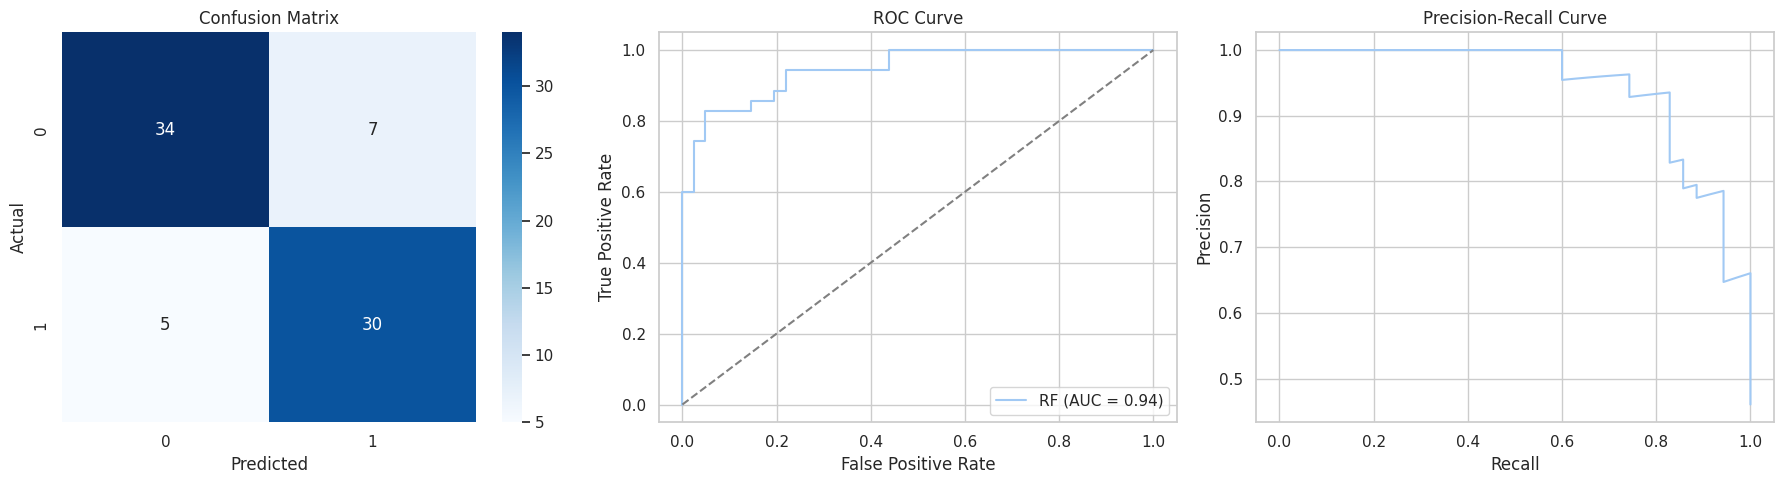

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'RF (AUC = {auc(fpr, tpr):.2f})')
axes[1].plot([0, 1], [0, 1], '--', color='grey')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(rec, prec)
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')

plt.tight_layout()
plt.show()

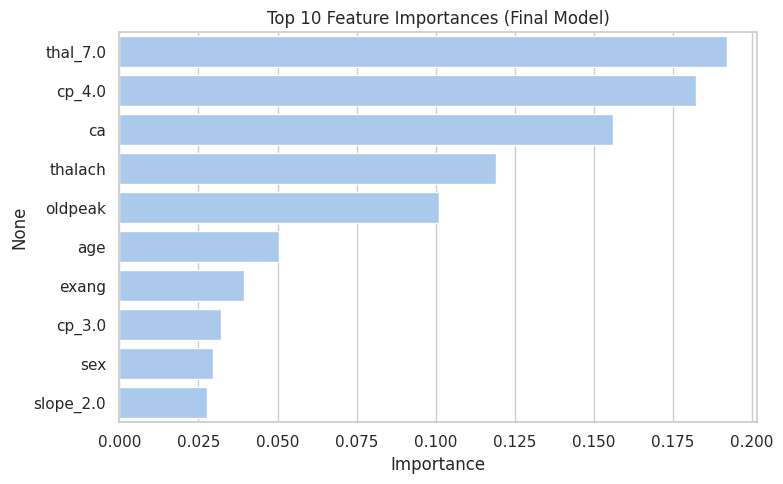

In [29]:
importances = pd.Series(final_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top 10 Feature Importances (Final Model)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 3. Ethical Considerations

Beyond overall accuracy, we check whether the model treats patient groups fairly. Below we measure accuracy separately for male and female patients, since the Cleveland cohort is skewed toward men.

In [30]:
for code_val, label in [(1, 'Male'), (0, 'Female')]:
    mask = (sex_test == code_val).values
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred[mask])
        print(f'{label:7s} (n={mask.sum():2d}) accuracy: {acc:.3f}')

Male    (n=50) accuracy: 0.820
Female  (n=26) accuracy: 0.885


**Ethical reflection**

- **Bias / representativeness:** the dataset is small (~300 patients) and male-skewed, so performance may differ by sex — the check above makes that gap visible rather than hidden.
- **Demographic performance:** any real deployment should be validated across age, sex, and ethnicity before being trusted.
- **Transparency:** we report feature importances and keep an interpretable logistic-regression alternative so clinicians can understand the drivers.
- **Privacy:** patient data is sensitive and would require HIPAA-compliant handling, anonymization, and secure storage.
- **Human in the loop:** the model is a screening aid, not a replacement for a doctor's diagnosis.

## 4. Real-World Application

**Where it fits.** This model could power a quick screening flag inside a clinic's electronic health record system. When a patient's basic measurements are entered, the model could surface a risk score that helps a clinician decide whether to order further cardiac testing.

**Who benefits.** Clinicians get a fast second opinion, patients get earlier attention when risk is high, and hospitals can prioritize limited testing capacity toward the people most likely to need it.

**Deployment notes.** The model is lightweight and runs in milliseconds, so it could be served as a simple API. It would need monitoring for data drift, periodic retraining on larger and more diverse data, and a clear disclaimer that it supports rather than replaces clinical judgment.

**Limitations.** Trained on 303 patients from one source, it is a proof of concept. Before real use it would need validation on a much larger, multi-hospital dataset.

## 5. Final Thoughts and Conclusion

Across both deliverables we took the project from raw data to a tuned, evaluated, and ethically-reviewed model. Hyperparameter tuning gave us a stable Random Forest, and the final evaluation showed strong, balanced performance with a good ROC-AUC and low false negatives — the error that matters most in a medical screening setting. The fairness check reminded us that good overall accuracy can still hide group differences. If we continued, we would gather a larger and more representative dataset, try gradient-boosted models, and add model explainability tools such as SHAP. Overall, this project showed us the full lifecycle of a real analytics solution, from problem framing to responsible deployment.